In [1]:
import numpy
import pandas

import matplotlib.pyplot as pyplot
import seaborn

In [8]:
ingresos = pandas.read_csv("ingresos_CDMX_2024.csv")

ingresos.head()

,ciclo,periodo,tipo_recurso_clase,desc_tipo_recurso_clase,rubro,desc_rubro,tipo,desc_tipo,clase,desc_clase,concepto,desc_concepto,concepto_especifico,desc_concepto_esp,monto_estimado,monto_recaudado
0,2020,Primer Trimestre,1,Ingresos locales,1,Impuestos,1.3,"Impuestos sobre la producción, el consumo y la...",1.3.1,Sobre Espectáculos Públicos,NaN,NaN,NaN,NaN,118840308.0,3.829086e+07
1,2020,Primer Trimestre,1,Ingresos locales,1,Impuestos,1.3,"Impuestos sobre la producción, el consumo y la...",1.3.2,"Sobre Loterías, Rifas, Sorteos y Concursos",NaN,NaN,NaN,NaN,129942832.0,1.317353e+08
2,2020,Primer Trimestre,1,Ingresos locales,1,Impuestos,1.3,"Impuestos sobre la producción, el consumo y la...",1.3.5,Por las Erogaciones en Juegos con Apuestas,NaN,NaN,NaN,NaN,56751313.0,5.559003e+07
3,2020,Primer Trimestre,1,Ingresos locales,1,Impuestos,1.7,Accesorios de los Impuestos,1.7.1,Accesorios de los Impuestos,NaN,NaN,NaN,NaN,110672274.0,1.376575e+08
4,2020,Primer Trimestre,1,Ingresos locales,4,Derechos,4.1,"Derechos por el uso, goce, aprovechamiento o e...",4.1.3,Por el Uso o Aprovechamiento de Inmuebles,NaN,NaN,NaN,NaN,39187834.0,3.450881e+07


In [9]:
ingresos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1263 entries, 0 to 1262
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ciclo                    1263 non-null   int64  
 1   periodo                  1263 non-null   object 
 2   tipo_recurso_clase       1263 non-null   int64  
 3   desc_tipo_recurso_clase  1263 non-null   object 
 4   rubro                    1263 non-null   int64  
 5   desc_rubro               1263 non-null   object 
 6   tipo                     1263 non-null   float64
 7   desc_tipo                1263 non-null   object 
 8   clase                    1187 non-null   object 
 9   desc_clase               1187 non-null   object 
 10  concepto                 423 non-null    object 
 11  desc_concepto            423 non-null    object 
 12  concepto_especifico      93 non-null     object 
 13  desc_concepto_esp        93 non-null     object 
 14  monto_estimado          

In [14]:
ingresos_a = ingresos[["ciclo", "periodo", "desc_rubro", "desc_tipo", "desc_clase", "monto_recaudado"]].copy()

ingresos_a.head()

,ciclo,periodo,desc_rubro,desc_tipo,desc_clase,monto_recaudado
0,2020,Primer Trimestre,Impuestos,"Impuestos sobre la producción, el consumo y la...",Sobre Espectáculos Públicos,3.829086e+07
1,2020,Primer Trimestre,Impuestos,"Impuestos sobre la producción, el consumo y la...","Sobre Loterías, Rifas, Sorteos y Concursos",1.317353e+08
2,2020,Primer Trimestre,Impuestos,"Impuestos sobre la producción, el consumo y la...",Por las Erogaciones en Juegos con Apuestas,5.559003e+07
3,2020,Primer Trimestre,Impuestos,Accesorios de los Impuestos,Accesorios de los Impuestos,1.376575e+08
4,2020,Primer Trimestre,Derechos,"Derechos por el uso, goce, aprovechamiento o e...",Por el Uso o Aprovechamiento de Inmuebles,3.450881e+07


In [15]:
ingresos_a["periodo"].unique()

array(['Primer Trimestre', 'Segundo Trimestre', 'Tercer Trimestre'],
      dtype=object)

In [16]:
ingresos_a["periodo"] = ingresos_a["periodo"].map({
    "Primer Trimestre": 1, 
    "Segundo Trimestre": 2, 
    "Tercer Trimestre": 3
})

ingresos_a.head()

,ciclo,periodo,desc_rubro,desc_tipo,desc_clase,monto_recaudado
0,2020,1,Impuestos,"Impuestos sobre la producción, el consumo y la...",Sobre Espectáculos Públicos,3.829086e+07
1,2020,1,Impuestos,"Impuestos sobre la producción, el consumo y la...","Sobre Loterías, Rifas, Sorteos y Concursos",1.317353e+08
2,2020,1,Impuestos,"Impuestos sobre la producción, el consumo y la...",Por las Erogaciones en Juegos con Apuestas,5.559003e+07
3,2020,1,Impuestos,Accesorios de los Impuestos,Accesorios de los Impuestos,1.376575e+08
4,2020,1,Derechos,"Derechos por el uso, goce, aprovechamiento o e...",Por el Uso o Aprovechamiento de Inmuebles,3.450881e+07


In [25]:
periodos = pandas.PeriodIndex.from_fields(year=ingresos_a["ciclo"], quarter=ingresos_a["periodo"])

periodos.name = "Fecha"

periodos

PeriodIndex(['2020Q1', '2020Q1', '2020Q1', '2020Q1', '2020Q1', '2020Q1',
             '2020Q1', '2020Q1', '2020Q1', '2020Q1',
             ...
             '2024Q1', '2024Q1', '2024Q1', '2024Q1', '2024Q1', '2024Q1',
             '2024Q1', '2024Q1', '2024Q1', '2024Q1'],
            dtype='period[Q-DEC]', name='Fecha', length=1263)

In [27]:
ingresos_a.index = periodos.to_timestamp("D")

ingresos_a.head()

,ciclo,periodo,desc_rubro,desc_tipo,desc_clase,monto_recaudado
Fecha,,,,,,
2020-01-01,2020,1,Impuestos,"Impuestos sobre la producción, el consumo y la...",Sobre Espectáculos Públicos,3.829086e+07
2020-01-01,2020,1,Impuestos,"Impuestos sobre la producción, el consumo y la...","Sobre Loterías, Rifas, Sorteos y Concursos",1.317353e+08
2020-01-01,2020,1,Impuestos,"Impuestos sobre la producción, el consumo y la...",Por las Erogaciones en Juegos con Apuestas,5.559003e+07
2020-01-01,2020,1,Impuestos,Accesorios de los Impuestos,Accesorios de los Impuestos,1.376575e+08
2020-01-01,2020,1,Derechos,"Derechos por el uso, goce, aprovechamiento o e...",Por el Uso o Aprovechamiento de Inmuebles,3.450881e+07


In [29]:
ingresos_b = ingresos_a[["desc_rubro", "desc_tipo", "desc_clase", "monto_recaudado"]].copy()

ingresos_b.copy()

,desc_rubro,desc_tipo,desc_clase,monto_recaudado
Fecha,,,,
2020-01-01,Impuestos,"Impuestos sobre la producción, el consumo y la...",Sobre Espectáculos Públicos,3.829086e+07
2020-01-01,Impuestos,"Impuestos sobre la producción, el consumo y la...","Sobre Loterías, Rifas, Sorteos y Concursos",1.317353e+08
2020-01-01,Impuestos,"Impuestos sobre la producción, el consumo y la...",Por las Erogaciones en Juegos con Apuestas,5.559003e+07
2020-01-01,Impuestos,Accesorios de los Impuestos,Accesorios de los Impuestos,1.376575e+08
2020-01-01,Derechos,"Derechos por el uso, goce, aprovechamiento o e...",Por el Uso o Aprovechamiento de Inmuebles,3.450881e+07
...,...,...,...,...
2024-01-01,"Participaciones, Aportaciones, Convenios, Ince...",Incentivos derivados de la colaboración fiscal,Por Multas Administrativas Impuestas por Autor...,7.913704e+06
2024-01-01,"Participaciones, Aportaciones, Convenios, Ince...",Incentivos derivados de la colaboración fiscal,Fondo de Compensación del ISAN,1.926162e+08
2024-01-01,"Participaciones, Aportaciones, Convenios, Ince...",Incentivos derivados de la colaboración fiscal,Fondo de Compensación del Régimen de Pequeños ...,2.683134e+07


In [33]:
ingresos_b["desc_clase"] = ingresos_b["desc_clase"].fillna("No-Especificado")

ingresos_b.sample(5)

,desc_rubro,desc_tipo,desc_clase,monto_recaudado
Fecha,,,,
2021-04-01,"Participaciones, Aportaciones, Convenios, Ince...",Incentivos derivados de la colaboración fiscal,Por la Participación de la Recaudación de Impu...,5.666305e+06
2019-07-01,"Participaciones, Aportaciones, Convenios, Ince...",Aportaciones,Fondo de Aportaciones para la Infraestructura ...,1.094863e+09
2019-04-01,Ingresos Derivados de Financiamientos,Endeudamiento Interno,No-Especificado,-2.039534e+09
2020-07-01,Derechos,Derechos por prestación de servicios,Por los Servicios de Expedición de Licencias,2.194539e+08
2022-04-01,Derechos,"Derechos por el uso, goce, aprovechamiento o e...",Por el Uso o Aprovechamiento de Inmuebles,5.086783e+07


<Axes: xlabel='Fecha'>

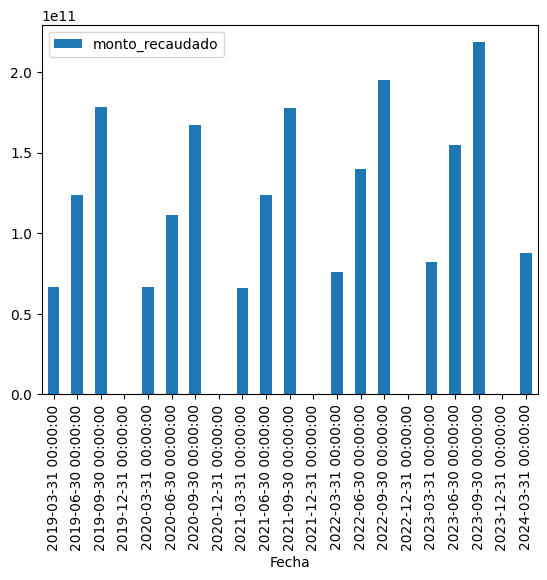

In [41]:
ingresos_b.resample("QE").sum().plot.bar()

<Axes: xlabel='Fecha'>

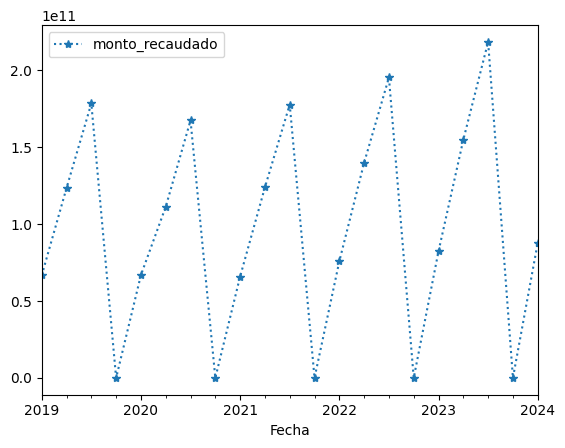

In [43]:
ingresos_b.resample("QE").sum().plot(marker="*", linestyle="dotted")

<Axes: xlabel='Fecha'>

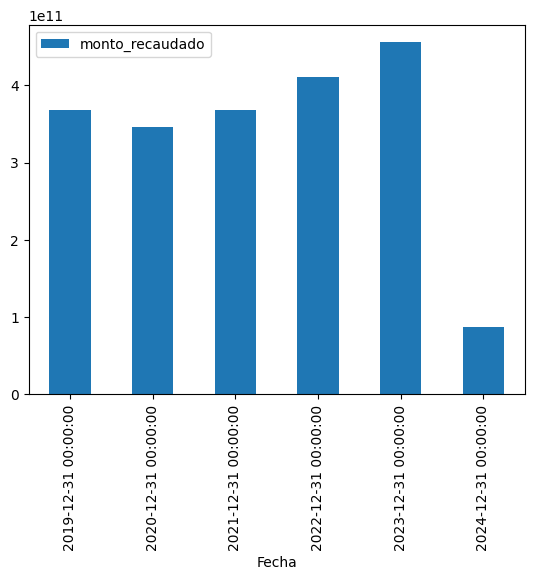

In [44]:
ingresos_b.resample("YE").sum().plot.bar()

In [50]:
ingresos_b.groupby("desc_rubro")[["monto_recaudado"]].sum()

,monto_recaudado
desc_rubro,
Aprovechamientos,5.423755e+10
Cuotas y Aportaciones de Seguridad Social,2.913260e+10
Derechos,1.103223e+11
Impuestos,6.199681e+11
Ingresos Derivados de Financiamientos,-4.007525e+10
"Ingresos por Venta de Bienes, Prestación de Servicios y Otros Ingresos",1.221683e+11
"Participaciones, Aportaciones, Convenios, Incentivos Derivados de la Colaboración Fiscal y Fondos Distintos de Aportaciones",1.040840e+12
Productos,9.892880e+10


<Axes: xlabel='desc_rubro'>

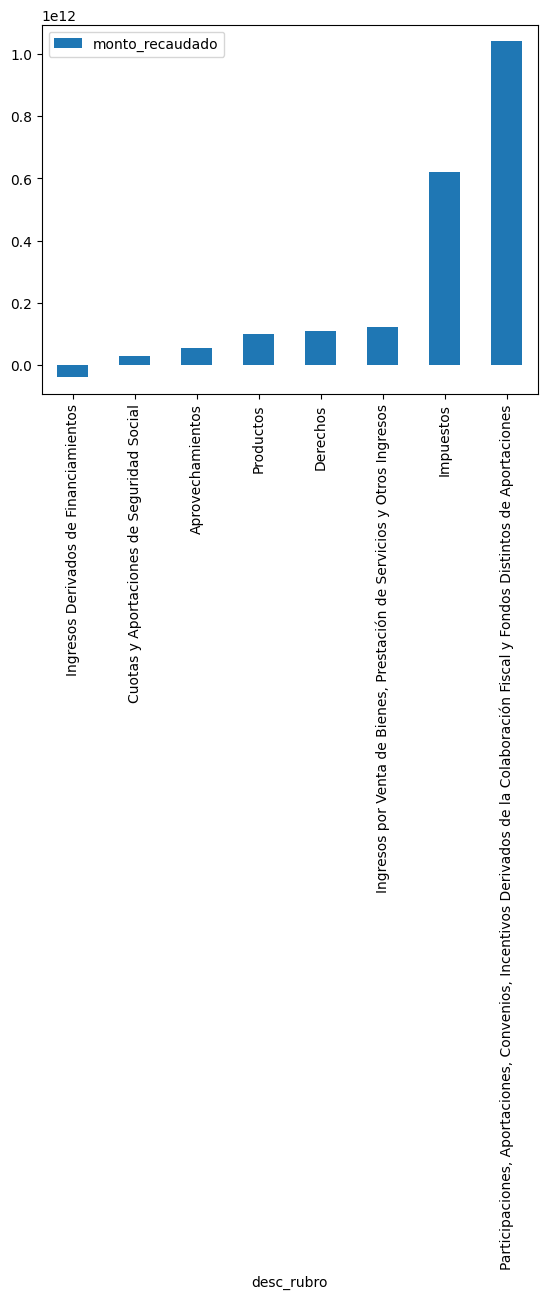

In [60]:
ingresos_b.groupby("desc_rubro")[["monto_recaudado"]].sum().sort_values("monto_recaudado").plot.bar()

In [62]:
ingresos_b["año"] = ingresos_b.index.year

ingresos_b.head()

,desc_rubro,desc_tipo,desc_clase,monto_recaudado,año
Fecha,,,,,
2020-01-01,Impuestos,"Impuestos sobre la producción, el consumo y la...",Sobre Espectáculos Públicos,3.829086e+07,2020
2020-01-01,Impuestos,"Impuestos sobre la producción, el consumo y la...","Sobre Loterías, Rifas, Sorteos y Concursos",1.317353e+08,2020
2020-01-01,Impuestos,"Impuestos sobre la producción, el consumo y la...",Por las Erogaciones en Juegos con Apuestas,5.559003e+07,2020
2020-01-01,Impuestos,Accesorios de los Impuestos,Accesorios de los Impuestos,1.376575e+08,2020
2020-01-01,Derechos,"Derechos por el uso, goce, aprovechamiento o e...",Por el Uso o Aprovechamiento de Inmuebles,3.450881e+07,2020


In [76]:
ingresos_b.groupby(["año", "desc_clase"]).sum().sort_values(["año", "monto_recaudado"], ascending=[True, False]).groupby("año").head(5)

desc_rubro  \
año  desc_clase                                                                                              
2019 Fondo General de Participaciones                    Participaciones, Aportaciones, Convenios, Ince...   
     Predial                                                                   ImpuestosImpuestosImpuestos   
     Sobre Nóminas                                                             ImpuestosImpuestosImpuestos   
     Productos derivados del uso y aprovechamiento d...  ProductosProductosProductosProductosProductosP...   
     No-Especificado                                     Ingresos Derivados de FinanciamientosIngresos ...   
2020 Fondo General de Participaciones                    Participaciones, Aportaciones, Convenios, Ince...   
     Predial                                                                   ImpuestosImpuestosImpuestos   
     Sobre Nóminas                                                             ImpuestosImpuestosImpuestos   
     Productos derivados del uso y aprovechamiento d...  ProductosProductosProductosProductosProductosP...   
     Por ingresos derivados del entero de impuestos      Participaciones, Aportaciones, Convenios, Ince...   
2021 Fondo General de Participaciones                    Participaciones, Aportaciones, Convenios, Ince...   
     Predial                                                                   ImpuestosImpuestosImpuestos   
     Sobre Nóminas                                                             ImpuestosImpuestosImpuestos   
     No-Especificado                                     Ingresos por Venta de Bienes, Prestación de Se...   
     Por ingresos derivados del entero de impuestos      Participaciones, Aportaciones, Convenios, Ince...   
2022 Fondo General de Participaciones                    Participaciones, Aportaciones, Convenios, Ince...   
     Predial                                                                   ImpuestosImpuestosImpuestos   
     Sobre Nóminas                                                             ImpuestosImpuestosImpuestos   
     Por ingresos derivados del entero de impuestos      Participaciones, Aportaciones, Convenios, Ince...   
     Convenios con la Federación                         Participaciones, Aportaciones, Convenios, Ince...   
2023 Fondo General de Participaciones                    Participaciones, Aportaciones, Convenios, Ince...   
     Sobre Nóminas                                                             ImpuestosImpuestosImpuestos   
     Predial                                                                   ImpuestosImpuestosImpuestos   
     No-Especificado                                     Ingresos por Venta de Bienes, Prestación de Se...   
     Por ingresos derivados del entero de impuestos      Participaciones, Aportaciones, Convenios, Ince...   
2024 Fondo General de Participaciones                    Participaciones, Aportaciones, Convenios, Ince...   
     Predial                                                                                     Impuestos   
     Sobre Nóminas                                                                               Impuestos   
     Por ingresos derivados del entero de impuestos      Participaciones, Aportaciones, Convenios, Ince...   
     Sobre Tenencia o Uso de Vehículos                                                           Impuestos   

                                                                                                 desc_tipo  \
año  desc_clase                                                                                              
2019 Fondo General de Participaciones                        ParticipacionesParticipacionesParticipaciones   
     Predial                                             Impuestos sobre el patrimonioImpuestos sobre e...   
     Sobre Nóminas                                       Impuestos sobre Nóminas y AsimilablesImpuestos...   
     Productos derivados 

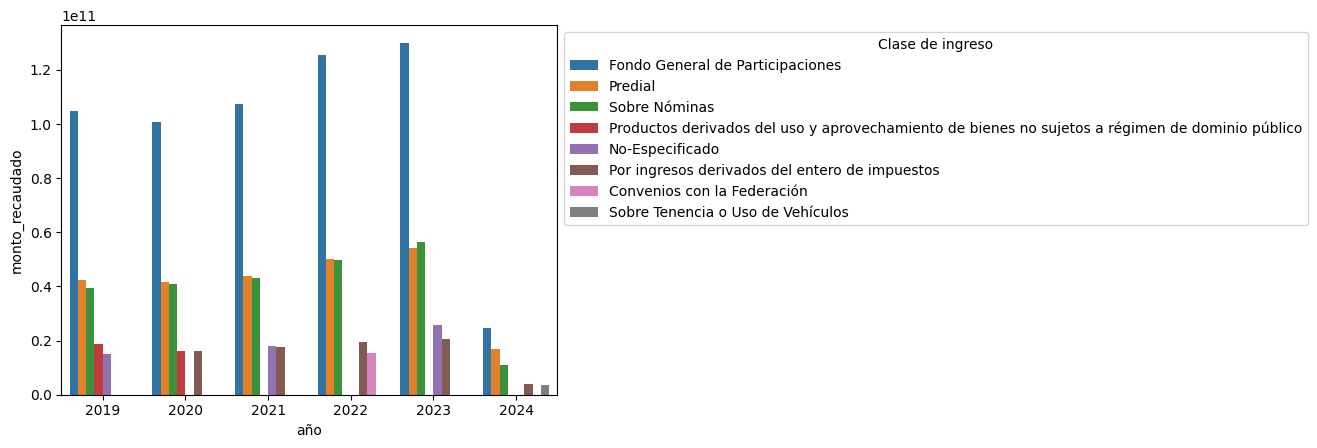

In [82]:
top_anual = ingresos_b.groupby(["año", "desc_clase"]).sum().sort_values(["año", "monto_recaudado"], ascending=[True, False]).groupby("año").head(5)

seaborn.barplot(top_anual, x="año", y="monto_recaudado", hue="desc_clase")
pyplot.legend(title="Clase de ingreso", bbox_to_anchor=(1, 1))

## Deuda pública

In [80]:
deuda = pandas.read_csv("deuda_publica_2025_03.csv")

deuda.head()

,anio,trimestre,mes,no_registro,tipo_deuda,detalle_tipo_deuda,acreedor,concepto,inicio_credito,fin_credito,...,disposicion_inicial_credito,colocacion_periodo,amortizaciones_periodo,intereses_periodo,pago_servicio_deuda,saldo_periodo,endeudamiento_periodo,tasa,sobretasa,tasa_final
0,2018,Cuarto Trimestre,Diciembre,145/2010,Largo Plazo,Mercado de Capitales,CI BANCO,BONO GDFCB 10-2,2010-06-25,2020-06-12,...,2.520951e+09,0.0,0.000000e+00,2.013680e+08,201367979.7,2.520951e+09,0.000000e+00,7.9,NaN,7.9
1,2018,Cuarto Trimestre,Diciembre,224/2007,Largo Plazo,Banca Comercial,BANCOMER,"BANCOMER 3,457",2007-08-30,1937-07-27,...,3.457974e+09,0.0,1.480940e+07,2.860966e+08,300906043.8,3.389146e+09,-1.480940e+07,TIIE,0.35,TIIE+0.35
2,2018,Cuarto Trimestre,Diciembre,225/2007,Largo Plazo,Banca Comercial,BANCOMER,BANCOMER 7000,2007-08-31,1940-08-27,...,7.000000e+09,0.0,1.089195e+08,5.809492e+08,689868613.7,6.371209e+09,-1.089195e+08,8.91,NaN,8.91
3,2018,Cuarto Trimestre,Diciembre,226/2007,Largo Plazo,Banca Comercial,BANCOMER,"BANCOMER 4,700",2007-08-31,1937-07-27,...,4.700000e+09,0.0,2.012859e+07,4.018697e+08,421998256.2,4.606450e+09,-2.012859e+07,8.8,NaN,8.8
4,2018,Cuarto Trimestre,Diciembre,513/2008,Largo Plazo,Banca de Desarrollo,BANOBRAS,"BANOBRAS 1,914",2008-12-26,2019-10-25,...,1.914681e+09,0.0,3.203735e+08,2.445093e+07,344824428.5,1.277433e+08,-3.203735e+08,TIIE,0.97,TIIE+0.97


In [83]:
deuda["mes"].unique()

array(['Diciembre', 'Marzo', 'Junio', 'Septiembre'], dtype=object)

In [84]:
deuda["mes"] = deuda["mes"].map({
    "Diciembre": 12, "Marzo": 3, "Junio": 6, "Septiembre": 9
})

deuda.head()

,anio,trimestre,mes,no_registro,tipo_deuda,detalle_tipo_deuda,acreedor,concepto,inicio_credito,fin_credito,...,disposicion_inicial_credito,colocacion_periodo,amortizaciones_periodo,intereses_periodo,pago_servicio_deuda,saldo_periodo,endeudamiento_periodo,tasa,sobretasa,tasa_final
0,2018,Cuarto Trimestre,12,145/2010,Largo Plazo,Mercado de Capitales,CI BANCO,BONO GDFCB 10-2,2010-06-25,2020-06-12,...,2.520951e+09,0.0,0.000000e+00,2.013680e+08,201367979.7,2.520951e+09,0.000000e+00,7.9,NaN,7.9
1,2018,Cuarto Trimestre,12,224/2007,Largo Plazo,Banca Comercial,BANCOMER,"BANCOMER 3,457",2007-08-30,1937-07-27,...,3.457974e+09,0.0,1.480940e+07,2.860966e+08,300906043.8,3.389146e+09,-1.480940e+07,TIIE,0.35,TIIE+0.35
2,2018,Cuarto Trimestre,12,225/2007,Largo Plazo,Banca Comercial,BANCOMER,BANCOMER 7000,2007-08-31,1940-08-27,...,7.000000e+09,0.0,1.089195e+08,5.809492e+08,689868613.7,6.371209e+09,-1.089195e+08,8.91,NaN,8.91
3,2018,Cuarto Trimestre,12,226/2007,Largo Plazo,Banca Comercial,BANCOMER,"BANCOMER 4,700",2007-08-31,1937-07-27,...,4.700000e+09,0.0,2.012859e+07,4.018697e+08,421998256.2,4.606450e+09,-2.012859e+07,8.8,NaN,8.8
4,2018,Cuarto Trimestre,12,513/2008,Largo Plazo,Banca de Desarrollo,BANOBRAS,"BANOBRAS 1,914",2008-12-26,2019-10-25,...,1.914681e+09,0.0,3.203735e+08,2.445093e+07,344824428.5,1.277433e+08,-3.203735e+08,TIIE,0.97,TIIE+0.97


In [86]:
periodos = pandas.PeriodIndex.from_fields(year=deuda["anio"], month=deuda["mes"], freq="M")

periodos.name = "Fecha"

periodos

PeriodIndex(['2018-12', '2018-12', '2018-12', '2018-12', '2018-12', '2018-12',
             '2018-12', '2018-12', '2018-12', '2018-12',
             ...
             '2025-03', '2025-03', '2025-03', '2025-03', '2025-03', '2025-03',
             '2025-03', '2025-03', '2025-03', '2025-03'],
            dtype='period[M]', name='Fecha', length=1141)

In [88]:
deuda.index = periodos.to_timestamp("D")

deuda.head()

,anio,trimestre,mes,no_registro,tipo_deuda,detalle_tipo_deuda,acreedor,concepto,inicio_credito,fin_credito,...,disposicion_inicial_credito,colocacion_periodo,amortizaciones_periodo,intereses_periodo,pago_servicio_deuda,saldo_periodo,endeudamiento_periodo,tasa,sobretasa,tasa_final
Fecha,,,,,,,,,,,,,,,,,,,,,
2018-12-01,2018,Cuarto Trimestre,12,145/2010,Largo Plazo,Mercado de Capitales,CI BANCO,BONO GDFCB 10-2,2010-06-25,2020-06-12,...,2.520951e+09,0.0,0.000000e+00,2.013680e+08,201367979.7,2.520951e+09,0.000000e+00,7.9,NaN,7.9
2018-12-01,2018,Cuarto Trimestre,12,224/2007,Largo Plazo,Banca Comercial,BANCOMER,"BANCOMER 3,457",2007-08-30,1937-07-27,...,3.457974e+09,0.0,1.480940e+07,2.860966e+08,300906043.8,3.389146e+09,-1.480940e+07,TIIE,0.35,TIIE+0.35
2018-12-01,2018,Cuarto Trimestre,12,225/2007,Largo Plazo,Banca Comercial,BANCOMER,BANCOMER 7000,2007-08-31,1940-08-27,...,7.000000e+09,0.0,1.089195e+08,5.809492e+08,689868613.7,6.371209e+09,-1.089195e+08,8.91,NaN,8.91
2018-12-01,2018,Cuarto Trimestre,12,226/2007,Largo Plazo,Banca Comercial,BANCOMER,"BANCOMER 4,700",2007-08-31,1937-07-27,...,4.700000e+09,0.0,2.012859e+07,4.018697e+08,421998256.2,4.606450e+09,-2.012859e+07,8.8,NaN,8.8
2018-12-01,2018,Cuarto Trimestre,12,513/2008,Largo Plazo,Banca de Desarrollo,BANOBRAS,"BANOBRAS 1,914",2008-12-26,2019-10-25,...,1.914681e+09,0.0,3.203735e+08,2.445093e+07,344824428.5,1.277433e+08,-3.203735e+08,TIIE,0.97,TIIE+0.97


<Axes: xlabel='Fecha', ylabel='saldo_periodo'>

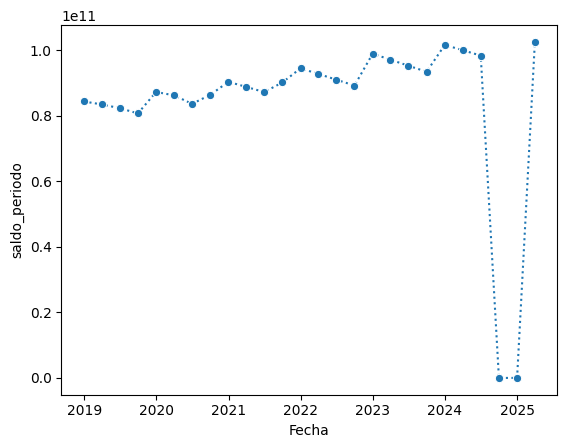

In [105]:
reporte = deuda.resample("QE").sum()

seaborn.lineplot(reporte, x=reporte.index, y="saldo_periodo", marker="o", linestyle="dotted")

<Axes: xlabel='Fecha', ylabel='pago_servicio_deuda'>

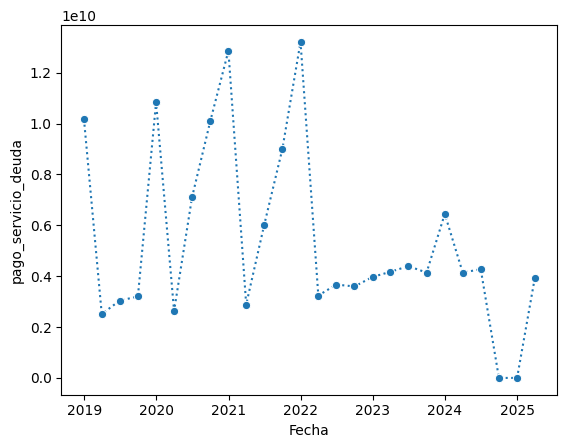

In [106]:
seaborn.lineplot(reporte, x=reporte.index, y="pago_servicio_deuda", marker="o", linestyle="dotted")

<Axes: xlabel='Fecha'>

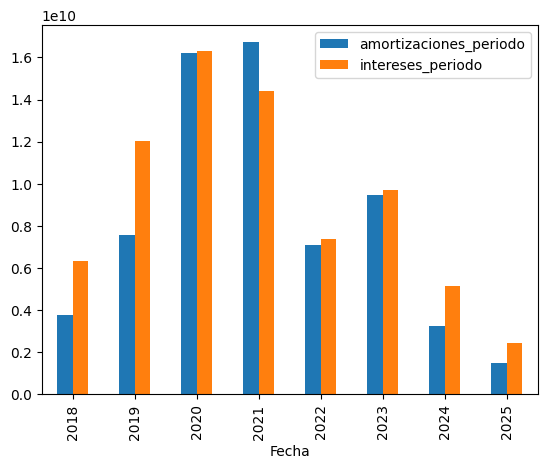

In [108]:
reporte2 = deuda[["amortizaciones_periodo", "intereses_periodo"]].groupby(deuda.index.year).sum()

reporte2.plot.bar()

Text(0, 0.5, '')

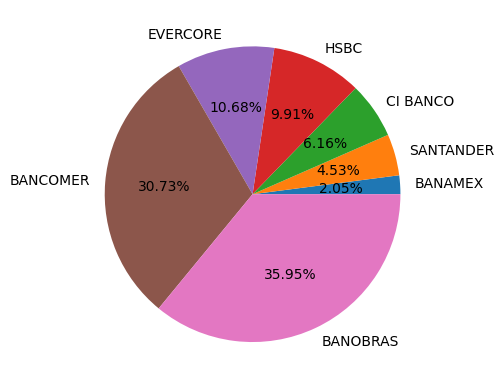

In [121]:
deuda.groupby("acreedor")["saldo_periodo"].sum().sort_values().plot.pie(autopct="%.2f%%")
pyplot.ylabel(None)

<Axes: xlabel='acreedor'>

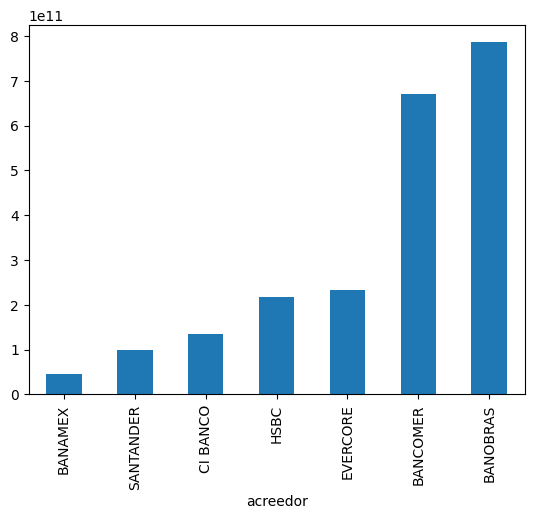

In [114]:
deuda.groupby("acreedor")["saldo_periodo"].sum().sort_values().plot.bar()


In [124]:
deuda["inicio_credito"] = pandas.to_datetime(deuda["inicio_credito"], errors="coerce")
deuda["fin_credito"] = pandas.to_datetime(deuda["fin_credito"], errors="coerce")

deuda["duracion_anios"] = (deuda["fin_credito"] - deuda["inicio_credito"]).dt.days / 365

deuda["duracion_anios"].describe()

count    1092.000000
mean        4.459150
std        28.967482
min       -90.106849
25%         9.961644
50%         9.997260
75%        15.008219
max        40.076712
Name: duracion_anios, dtype: float64

<Axes: ylabel='Frequency'>

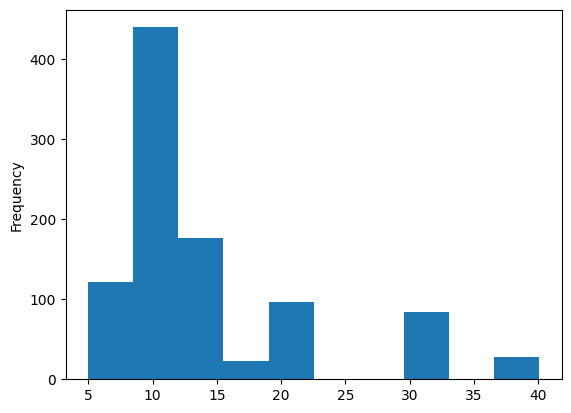

In [136]:
deuda["duracion_anios"][deuda["duracion_anios"] > 0].plot.hist()

<Axes: ylabel='Density'>

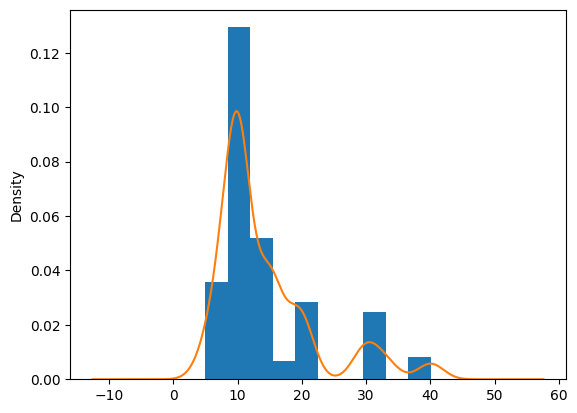

In [135]:
deuda["duracion_anios"][deuda["duracion_anios"] > 0].plot.hist(density=True)
deuda["duracion_anios"][deuda["duracion_anios"] > 0].plot.density()

<Axes: >

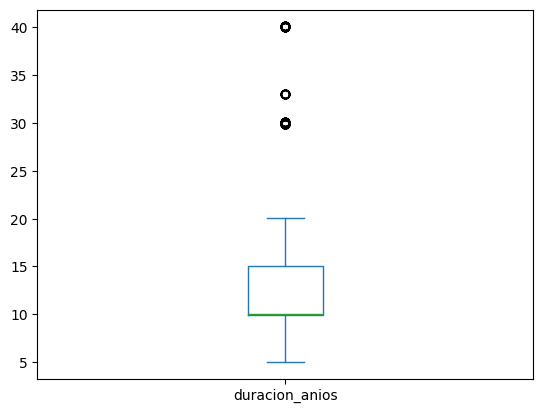

In [131]:
deuda["duracion_anios"][deuda["duracion_anios"] > 0].plot.box()